In [81]:
import pandas as pd
import sys
sys.path.append('/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/mirt-official') 
from load_params import load_and_rotate

resmat = pd.read_pickle("../data/resmat.pkl")

theta, a, b = load_and_rotate(rotation='oblimax', model_path='./output/mirt_model_k19.pt')

# varimax, oblimax, quartimax, equamax, geomin_ort, promax, oblimin, quartimin, geomin_obl

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

--- Loading from Cache ---
Loaded cached theta shape: (183, 19)
Loaded cached a shape: (78712, 19)
Loaded cached b shape: (78712,)



In [82]:
a_df_scenarios = pd.DataFrame(a, index=resmat.columns.get_level_values('scenario'), columns=factor_names)
# Group by similar index values and calculate mean
a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()

# Check the resulting shape
print(f"Original a_df shape: {a_df_scenarios.shape}")
print(f"Grouped a_df shape: {a_df_grouped.shape}")
print(f"Number of unique scenarios: {len(a_df_grouped.index)}")


Original a_df shape: (78712, 19)
Grouped a_df shape: (22, 19)
Number of unique scenarios: 22


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_92185/135264312.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a_df_grouped = a_df_scenarios.groupby(a_df_scenarios.index).mean().dropna()


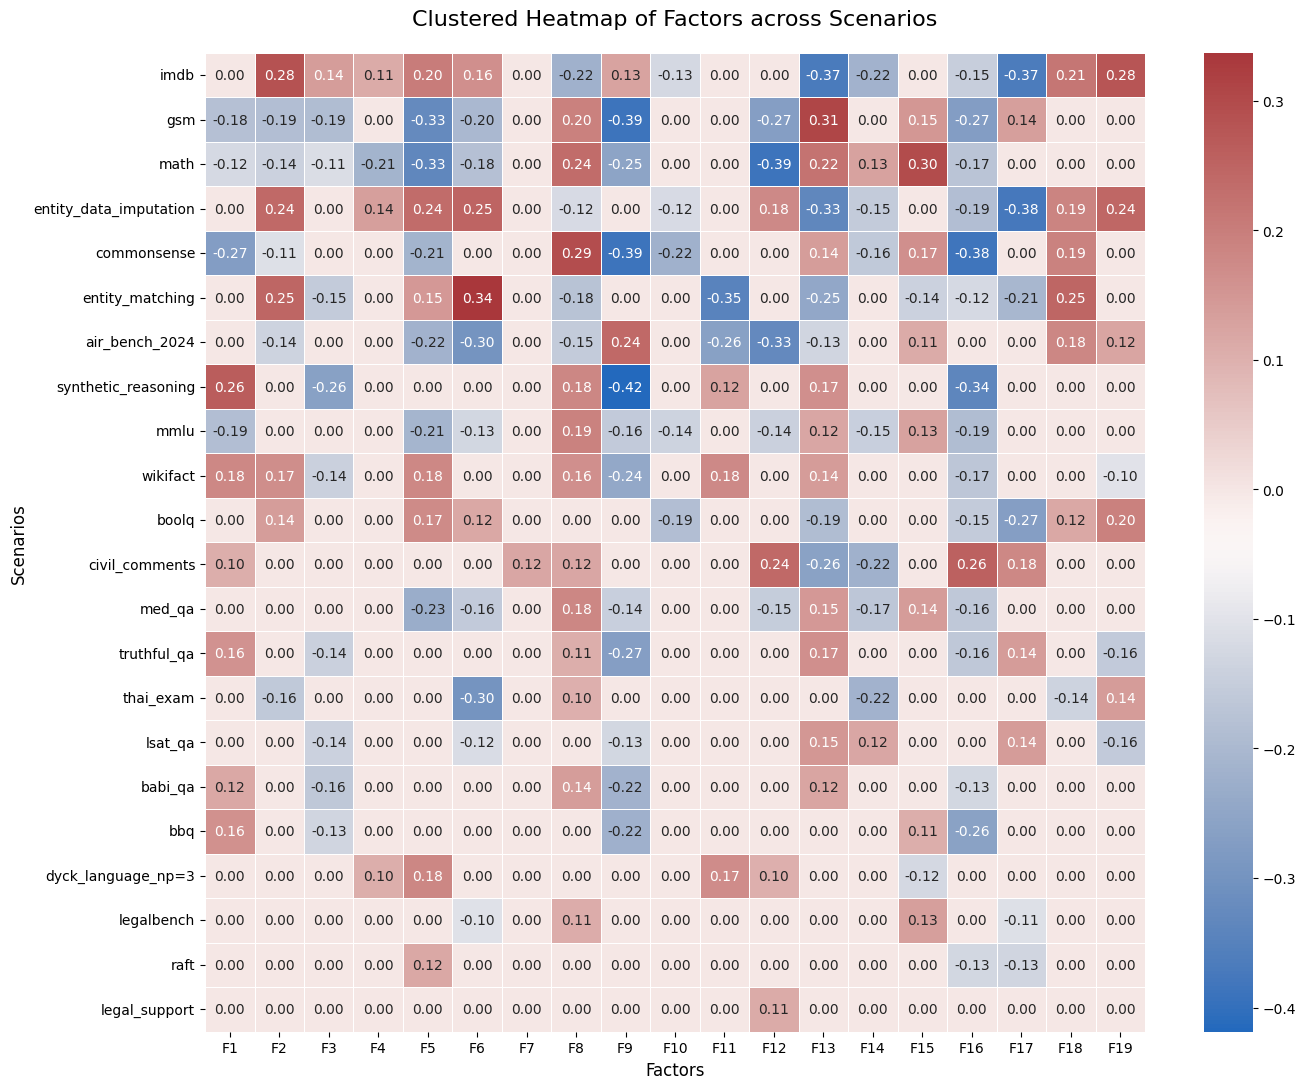

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

inspection = a_df_grouped.copy()
inspection[abs(inspection) < 0.1] = 0

# 1. Order rows by sum (scenarios with highest total loadings first) 
row_sums = inspection.abs().sum(axis=1)
row_order = row_sums.sort_values(ascending=False).index

# 2. Reorder inspection matrix - only reorder rows, keep columns in original order
ordered_inspection = inspection.loc[row_order, :]

# You can adjust figsize to make the plot larger or smaller for better readability.
fig, ax = plt.subplots(figsize=(14, 11))

# 2. Generate the clustered heatmap
# sns.heatmap is the core function here.
sns.heatmap(
    ordered_inspection,     # The clustered data to plot
    annot=True,       # Write the data value in each cell
    fmt=".2f",        # Use two decimal places for annotations
    cmap='vlag',  # Use the 'vlag' color map (blue-white-red)
    linewidths=.5,    # Add lines between cells
    ax=ax,
)

# 3. Add titles and labels for clarity
ax.set_title('Clustered Heatmap of Factors across Scenarios', fontsize=16, pad=20)
ax.set_xlabel('Factors', fontsize=12)
ax.set_ylabel('Scenarios', fontsize=12)

# 4. Ensure labels are not cut off
plt.tight_layout()

# 5. Display the plot
plt.show()

# To save the figure to a file, uncomment the line below
# fig.savefig('clustered_heatmap.png', dpi=300)

In [84]:
a_df_questions = pd.DataFrame(a, index=resmat.columns.get_level_values('input.text'), columns=factor_names)

In [85]:
top_k = 20  # Top items per scenario
loading_threshold = 0.1  # Minimum absolute loading for scenarios

for col in a_df_questions.columns:
    with open('factor_loadings_analysis_'+col+'.txt', 'w', encoding='utf-8') as f:
        f.write('='*80 + '\n')
        f.write(f'TOP LOADING ITEMS FOR FACTOR {col} (by Scenario)\n')
        f.write(f'Only scenarios with absolute loading > {loading_threshold}\n')
        f.write('='*80 + '\n')
        
        # Get scenarios with absolute loading > threshold
        qualifying_scenarios = a_df_grouped[abs(a_df_grouped[col]) > loading_threshold].index
        scenario_loadings = a_df_grouped.loc[qualifying_scenarios, col].sort_values(key=abs, ascending=False)
        
        f.write(f'\n📊 QUALIFYING SCENARIOS ({len(qualifying_scenarios)} total):\n')
        f.write('-'*50 + '\n')
        
        if len(qualifying_scenarios) == 0:
            f.write(f'No scenarios meet the threshold (|loading| > {loading_threshold})\n')
            f.write(f'Consider lowering the threshold or check factor loadings.\n\n')
            f.write('='*80 + '\n\n')
            continue
        
        for scenario, loading in scenario_loadings.items():
            f.write(f'{scenario}: {loading:.4f}\n')
        
        f.write('\n' + '='*80 + '\n')
        
        # For each qualifying scenario, get top loading questions
        for scenario in scenario_loadings.index:
            scenario_loading = scenario_loadings[scenario]
            
            # Get questions from this scenario
            scenario_mask = resmat.columns.get_level_values('scenario') == scenario
            scenario_questions = resmat.columns[scenario_mask].get_level_values('input.text')
            
            # Filter a_df_questions for this scenario
            scenario_question_loadings = a_df_questions.loc[scenario_questions, col].dropna()
            
            if len(scenario_question_loadings) == 0:
                continue
                
            f.write(f'\n🎯 SCENARIO: {scenario} (Factor Loading: {scenario_loading:.4f})\n')
            f.write('='*60 + '\n')
            
            # Get top positive loadings for this scenario
            if scenario_loading > 0:
                top_items = scenario_question_loadings.sort_values(ascending=False).head(top_k)
                f.write(f'📈 TOP {min(top_k, len(top_items))} POSITIVE LOADING ITEMS:\n')
            else:
                top_items = scenario_question_loadings.sort_values(ascending=True).head(top_k)
                f.write(f'📉 TOP {min(top_k, len(top_items))} NEGATIVE LOADING ITEMS:\n')
            
            f.write('-'*40 + '\n')
            
            for i, (question, loading) in enumerate(top_items.items(), 1):
                f.write(f'\n{i}. [[[Loading]]]: {loading:.4f}\n')
                f.write(f'   [[[Question]]]: {question}\n')
            
            f.write('\n' + '-'*60 + '\n')
        
        # Overall statistics
        f.write(f'\n📊 OVERALL STATISTICS FOR {col}:\n')
        f.write('-'*40 + '\n')
        f.write(f'Total scenarios analyzed: {len(qualifying_scenarios)}\n')
        f.write(f'Scenarios filtered out (|loading| <= {loading_threshold}): {len(a_df_grouped) - len(qualifying_scenarios)}\n')
        
        if len(scenario_loadings) > 0:
            f.write(f'Strongest scenario: {scenario_loadings.iloc[0]:.4f} ({scenario_loadings.index[0]})\n')
            f.write(f'Average absolute loading: {abs(scenario_loadings).mean():.3f}\n')
        else:
            f.write('No qualifying scenarios to analyze.\n')
        
        f.write('\n' + '='*80 + '\n\n')

print("Factor loadings analysis saved to individual files per factor")

Factor loadings analysis saved to individual files per factor


In [88]:
import numpy as np
import pandas as pd
from sklearn.decomposition import NMF

# ------------------------------
# 0. Input: rotated loadings (a)
# ------------------------------
# a: (n_items × n_dims), from your rotated MIRT solution
A = np.abs(a)  
A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-8)

# ------------------------------
# 1. Try multiple values of K (skills)
# ------------------------------
k_trials = [5, 10, 15, 19]   # <-- you can adjust this
results = {}

for n_skills in k_trials:
    nmf = NMF(
        n_components=n_skills, 
        init='nndsvda', 
        random_state=42, 
        max_iter=2000
    )
    W = nmf.fit_transform(A)   # items × skills
    H = nmf.components_        # skills × dims
    
    # Assign items to skills
    item_skill = np.argmax(W, axis=1)
    
    # Store results
    results[n_skills] = {
        "W": W,
        "H": H,
        "item_skill": item_skill
    }
    
    # Save assignments to CSV
    item_skill_df = pd.DataFrame({
        "item": np.arange(A.shape[0]),
        "assigned_skill": item_skill,
        "max_loading": W.max(axis=1)
    })
    item_skill_df.to_csv(f"item_skill_assignments_K{n_skills}.csv", index=False)
    
    # Save skill profile definitions
    skill_profiles = pd.DataFrame(
        H, 
        columns=[f"Dim{d+1}" for d in range(A.shape[1])]
    )
    skill_profiles.to_csv(f"skill_profiles_K{n_skills}.csv", index=False)

    print(f"[Saved] K={n_skills}: assignments + skill profiles")

# ------------------------------
# 2. After this:
# ------------------------------
# - For bi-factor: pick the K that best fits (theory or reconstruction error).
# - Build a mask matrix: items × K, with mask[i, g] = 1 if item i → skill g, else 0.


[Saved] K=5: assignments + skill profiles
[Saved] K=10: assignments + skill profiles
[Saved] K=15: assignments + skill profiles
[Saved] K=19: assignments + skill profiles


In [87]:
item_skill_df

,item,assigned_skill,max_loading
0,0,9,0.031151
1,1,8,0.038981
2,2,0,0.034617
3,3,7,0.032995
4,4,0,0.034045
...,...,...,...
78707,78707,5,0.037764
78708,78708,8,0.050727
78709,78709,9,0.070408
78710,78710,5,0.033128


In [71]:
theta_df = pd.DataFrame(theta, index=resmat.index, columns=factor_names)

In [72]:
theta_df['sum'] = theta_df.sum(axis=1)
theta_df.sort_values(by='sum', ascending=False, inplace=True)
theta_df.drop(columns=['sum'], inplace=True)
print(theta_df)

                                            F1        F2        F3        F4  \
request.model                                                                  
meta/llama-2-7b                       0.122287  0.035960  0.736077  0.443745   
tiiuae/falcon-7b                      1.162453  1.187033  0.753743  0.444400   
cohere/xlarge-20221108                0.628150  1.660406  0.128240  0.627261   
ai21/j1-grande-v2-beta                0.818873  2.341704  0.920379  0.331857   
ai21/j2-grande                        1.150621  1.245377  0.669113  0.031682   
...                                        ...       ...       ...       ...   
writer/palmyra-x-v3                  -0.800787 -0.200362 -0.868719 -0.922422   
anthropic/claude-3-sonnet-20240229   -0.794125 -1.520649 -0.908238  0.503697   
anthropic/claude-3-5-sonnet-20241022 -0.166371 -0.937772  0.270416  0.259384   
qwen/qwen2.5-72b-instruct-turbo      -1.884234 -0.921494 -0.389971  0.039358   
anthropic/claude-3-opus-20240229     -0.

In [73]:
from sklearn.decomposition import PCA
import numpy as np

# theta is your factor score matrix
pca = PCA(n_components=1)
g_scores = pca.fit_transform(theta)[:, 0]  # general composite

In [74]:
with pd.option_context('display.max_rows', 100):
  display(pd.DataFrame(g_scores, index=resmat.index, columns=['g_score']).sort_values(by='g_score', ascending=False))

,g_score
request.model,
deepseek-ai/deepseek-v3,3.357121
meta/llama-3.2-90b-vision-instruct-turbo,3.267058
meta/llama-3.1-70b-instruct-turbo,3.019625
meta/llama-3.1-405b-instruct-turbo,2.960796
meta/llama-3.3-70b-instruct-turbo,2.935962
...,...
ai21/j1-grande-v2-beta,-3.949758
ai21/j1-grande,-4.004394
tiiuae/falcon-7b,-4.245142


In [75]:
# Get mean scores and find common indices (models that have non-NaN values for both)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()
# count each company in common_indices
company_counts = {}
for model in common_indices:
    company = model.split('/')[0]
    if company not in company_counts:
        company_counts[company] = 0
    company_counts[company] += 1

In [76]:
score_1 = pd.Series(theta[:, 0], index=resmat.index)
score_2 = pd.Series(theta[:, 1], index=resmat.index)
score_3 = pd.Series(theta[:, 2], index=resmat.index)
score_4 = pd.Series(theta[:, 3], index=resmat.index)
score_5 = pd.Series(theta[:, 4], index=resmat.index)
score_6 = pd.Series(theta[:, 5], index=resmat.index)
score_7 = pd.Series(theta[:, 6], index=resmat.index)
score_8 = pd.Series(theta[:, 7], index=resmat.index)
score_9 = pd.Series(theta[:, 8], index=resmat.index)
score_10 = pd.Series(theta[:, 9], index=resmat.index)
score_11 = pd.Series(theta[:, 10], index=resmat.index)
score_12 = pd.Series(theta[:, 11], index=resmat.index)
score_13 = pd.Series(theta[:, 12], index=resmat.index)
score_14 = pd.Series(theta[:, 13], index=resmat.index)
score_15 = pd.Series(theta[:, 14], index=resmat.index)
score_16 = pd.Series(theta[:, 15], index=resmat.index)
score_17 = pd.Series(theta[:, 16], index=resmat.index)
score_18 = pd.Series(theta[:, 17], index=resmat.index)
score_19 = pd.Series(theta[:, 18], index=resmat.index)

request.model
meta/llama-2-7b                             0.464650
meta/llama-2-13b                            0.067561
meta/llama-3.1-70b-instruct-turbo          -0.103681
meta/llama-3.1-405b-instruct-turbo         -0.128575
meta/llama-3-8b                            -0.132401
meta/llama-3.2-90b-vision-instruct-turbo   -0.134021
meta/llama-3.1-8b-instruct-turbo           -0.140367
meta/llama-65b                             -0.153390
meta/llama-3.3-70b-instruct-turbo          -0.240364
meta/llama-2-70b                           -0.245642
meta/llama-3.2-11b-vision-instruct-turbo   -0.259387
meta/llama-3-70b                           -0.290542
dtype: float32
request.model
openai/text-davinci-002         -0.031521
openai/text-davinci-003         -0.083661
openai/gpt-4-1106-preview       -0.114262
openai/gpt-4o-mini-2024-07-18   -0.130935
openai/gpt-4o-2024-05-13        -0.152639
openai/gpt-4o-2024-08-06        -0.167170
openai/gpt-3.5-turbo-0613       -0.222924
openai/gpt-4-0613          

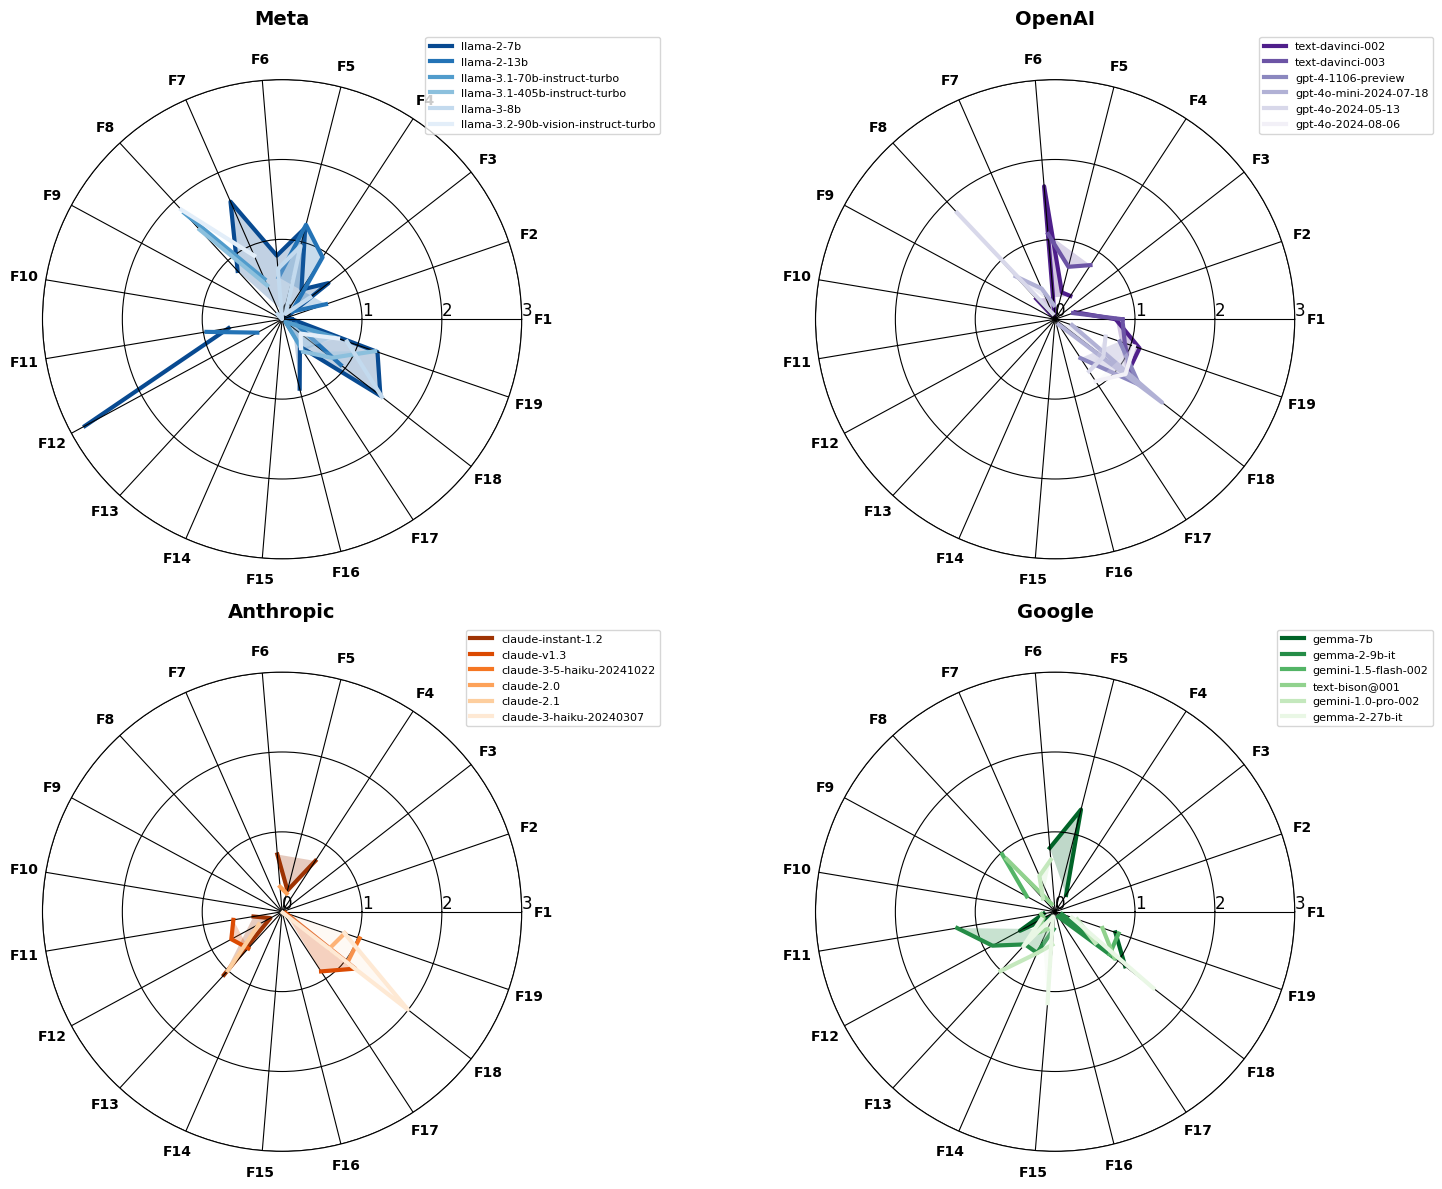

Selected models for radar charts:

META:
  meta/llama-2-7b
  meta/llama-2-13b
  meta/llama-3.1-70b-instruct-turbo
  meta/llama-3.1-405b-instruct-turbo
  meta/llama-3-8b
  meta/llama-3.2-90b-vision-instruct-turbo

OPENAI:
  openai/text-davinci-002
  openai/text-davinci-003
  openai/gpt-4-1106-preview
  openai/gpt-4o-mini-2024-07-18
  openai/gpt-4o-2024-05-13
  openai/gpt-4o-2024-08-06

ANTHROPIC:
  anthropic/claude-instant-1.2
  anthropic/claude-v1.3
  anthropic/claude-3-5-haiku-20241022
  anthropic/claude-2.0
  anthropic/claude-2.1
  anthropic/claude-3-haiku-20240307

GOOGLE:
  google/gemma-7b
  google/gemma-2-9b-it
  google/gemini-1.5-flash-002
  google/text-bison@001
  google/gemini-1.0-pro-002
  google/gemma-2-27b-it


In [77]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()

scores_mapping = {
    'F1': score_1,
    'F2': score_2,
    'F3': score_3,
    'F4': score_4,
    'F5': score_5,
    'F6': score_6,
    'F7': score_7,
    'F8': score_8,
    'F9': score_9,
    'F10': score_10,
    'F11': score_11,
    'F12': score_12,
    'F13': score_13,
    'F14': score_14,
    'F15': score_15,
    'F16': score_16,
    'F17': score_17,
    'F18': score_18,
    'F19': score_19,
}

skill_scores = pd.DataFrame(scores_mapping)

skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.25, zorder=i + 1)
    
    # Add labels
    ax.tick_params(pad=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_ylim(-3, 3)  # Set consistent scale
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=1, color='black', zorder=10)
    
    # Ensure y-ticks align with circles
    ax.set_rgrids([-3, -2, -1, 0, 1, 2, 3], angle=0, labels=["-3", "-2", "-1", "0", "1", "2", "3"], fontsize=12)

    # Hide the zero label
    ax.set_rmin(0)

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': [],
    'google': []
}

# Group models by company prefix (only include models that have all 4 skill scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith(('google/')):
        companies['google'].append(model)

# UPDATED VERSION: Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Define explicit models to include for each company
explicit_models_by_company = {
    'openai': ['openai/text-davinci-002'],
    # Add other companies and their explicit models as needed
    # 'anthropic': ['anthropic/claude-v1'],
    # 'google': ['google/specific-model'],
    # etc.
}

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models, 
        n=6, 
        explicit_models=explicit_models_by_company.get(company, [])
    ) 
    for company, models in companies.items()
}
# Create the radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels 
skill_labels = scores_mapping.keys()

company_names = ['Meta', 'OpenAI', 'Anthropic', 'Google']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'google':
            colors = plt.cm.Greens_r(np.linspace(0.1, 0.9, len(models)))
        create_radar_chart(model_data, skill_labels, company_name, axes[i], 
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(company_name, size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/model_families_math_skill_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("Selected models for radar charts:")
for company, models in selected_models.items():
    print(f"\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        print(f"  {model}")